### 0. Importations

Les bibliothèques nécessaires à l'exploration du corpus sont importées au début du notebook.

* `pandas` permet de charger et manipuler les données ;
* `matplotlib` permet de réaliser les premières visualisations.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### 1. Chargement des données

Le fichier `smart_reviews_raw.csv` contient le corpus brut d'avis clients.

Il est chargé depuis le dossier `data/` afin de conserver une organisation claire entre les données et le notebook.


In [4]:
df = pd.read_csv("../data/smart_review_raw.csv")

df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


### 1.2. Nombre d'avis

Le nombre d'avis correspond au nombre de lignes présentes dans le dataset.

In [5]:
nombre_avis = len(df)

print(f"Le dataset contient {nombre_avis} avis.")

Le dataset contient 1200 avis.


### 1.3. Nombre de colonnes

Le nombre de colonnes permet d'identifier les différentes informations disponibles pour chaque avis.

In [6]:
nombre_colonnes = df.shape[1]

print(f"Le dataset possède {nombre_colonnes} colonnes.")

Le dataset possède 8 colonnes.


### 1.4. Type des colonnes

L'analyse du type de chaque colonne permet de vérifier la nature des données avant de poursuivre leur traitement.

In [7]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

### 1.5. Valeurs manquantes

Le nombre de valeurs manquantes est vérifié pour chaque colonne afin d'identifier les éventuels problèmes de qualité du corpus.

In [8]:
valeurs_manquantes = df.isna().sum()

valeurs_manquantes

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

In [ ]:
# exprimees en %

pourcentage_manquant = (df.isna().mean() * 100).round(2)

pourcentage_manquant

id_avis      0.00
date         0.00
source       0.00
produit      0.00
texte        0.42
sentiment    0.00
note         0.00
langue       0.00
dtype: float64

### 1.6. Identification des différents types de texte

Le corpus contient différents types de textes présentant des caractéristiques particulières.

On recherche notamment les textes normaux, vides, contenant une URL, une mention, un hashtag, des emojis, beaucoup de ponctuation, uniquement ou majoritairement en majuscules, ainsi que des répétitions de caractères.

In [10]:
texte = df["texte"].fillna("").astype(str)

exemples = {
    "texte normal": texte[
        (texte.str.strip() != "") &
        ~texte.str.contains(r"https?://|www\.", regex=True) &
        ~texte.str.contains(r"@\w+", regex=True) &
        ~texte.str.contains(r"#\w+", regex=True)
    ],
    "texte vide": texte[texte.str.strip() == ""],
    "texte contenant une URL": texte[
        texte.str.contains(r"https?://|www\.", regex=True)
    ],
    "texte contenant une mention": texte[
        texte.str.contains(r"@\w+", regex=True)
    ],
    "texte contenant un hashtag": texte[
        texte.str.contains(r"#\w+", regex=True)
    ],
    "texte contenant un emoji": texte[
        texte.str.contains(r"[^\x00-\x7F]", regex=True)
    ],
    "beaucoup de ponctuation": texte[
        texte.str.count(r"[!?.,;:]") >= 3
    ],
    "texte en majuscules": texte[
        (texte.str.strip() != "") &
        (texte.str.upper() == texte) &
        texte.str.contains(r"[A-ZÀ-ÖØ-Þ]", regex=True)
    ],
    "répétition de caractères": texte[
        texte.str.contains(r"(.)\1{2,}", regex=True)
    ]
}

for categorie, exemples_trouves in exemples.items():
    print(f"\n--- {categorie} ---")
    
    if exemples_trouves.empty:
        print("Aucun exemple trouvé.")
    else:
        print(exemples_trouves.iloc[0])


--- texte normal ---
Très  bonne  expérience,  simple  et  efficace.

--- texte vide ---


--- texte contenant une URL ---
Produit parfait, rien à signaler. https://example.com/commande/17

--- texte contenant une mention ---
@client Livraison rapide et produit conforme à mes attentes.

--- texte contenant un hashtag ---
Très satisfait de mon achat 👍 #avis

--- texte contenant un emoji ---
Très  bonne  expérience,  simple  et  efficace.

--- beaucoup de ponctuation ---
Produit excellent, je suis très satisfait. !!!

--- texte en majuscules ---
LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.

--- répétition de caractères ---
Produit excellent, je suis très satisfait. !!!


C:\Users\Invite\AppData\Local\Temp\ipykernel_18192\605448104.py:32: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  texte.str.contains(r"(.)\1{2,}", regex=True)


### 1.7. Longueur des textes

Une nouvelle colonne `longueur` est créée afin de mesurer le nombre de caractères de chaque avis.

Les statistiques calculées sont la longueur minimale, la longueur maximale, la moyenne, la médiane ainsi que les quartiles.

In [12]:
df["longueur"] = df["texte"].fillna("").astype(str).str.len()

statistiques_longueur = df["longueur"].describe()

statistiques_longueur

count    1200.000000
mean       48.963333
std        22.350913
min         0.000000
25%        37.000000
50%        48.000000
75%        56.000000
max       636.000000
Name: longueur, dtype: float64

In [ ]:
# afficher

print(f"Longueur minimale : {df['longueur'].min()}")
print(f"Longueur maximale : {df['longueur'].max()}")
print(f"Longueur moyenne : {df['longueur'].mean():.2f}")
print(f"Médiane : {df['longueur'].median()}")
print(f"Premier quartile : {df['longueur'].quantile(0.25)}")
print(f"Troisième quartile : {df['longueur'].quantile(0.75)}")

Longueur minimale : 0
Longueur maximale : 636
Longueur moyenne : 48.96
Médiane : 48.0
Premier quartile : 37.0
Troisième quartile : 56.0


### 1.8. Distribution de la longueur des avis

La distribution des longueurs est visualisée afin d'identifier d'éventuels textes anormalement longs ainsi que la présence de nombreux textes très courts.

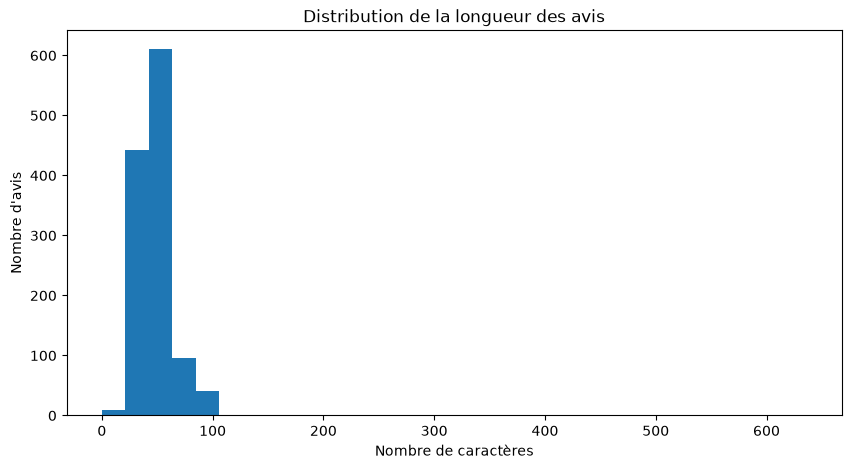

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(df["longueur"], bins=30)

plt.title("Distribution de la longueur des avis")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre d'avis")

plt.show()

In [ ]:
# objectiver les equations avec les quartiles

q1 = df["longueur"].quantile(0.25)
q3 = df["longueur"].quantile(0.75)
iqr = q3 - q1

borne_superieure = q3 + 1.5 * iqr

textes_anormalement_longs = df[df["longueur"] > borne_superieure]
textes_tres_courts = df[df["longueur"] <= q1]

print(f"Nombre de textes anormalement longs : {len(textes_anormalement_longs)}")
print(f"Nombre de textes très courts : {len(textes_tres_courts)}")

Nombre de textes anormalement longs : 41
Nombre de textes très courts : 329


#### a . b. Lecture

La distribution montre que la majorité des avis se concentre sur une plage de longueurs relativement courte. Les valeurs situées au-delà de la borne supérieure calculée sont considérées comme potentiellement anormalement longues.

- peu de texte court
- beaucoup d'avis particulièrement fournis
- donc inclus des textes anormalement longs 

La proportion de textes courts est également examinée afin de déterminer s'ils représentent une part importante du corpus.

### 1.9. Détection des textes vides

Les textes vides sont recherchés après suppression des espaces en début et en fin de chaîne.

In [16]:
textes_vides = df[
    df["texte"].isna() |
    (df["texte"].fillna("").str.strip() == "")
]

print(f"Nombre de textes vides : {len(textes_vides)}")

textes_vides

Nombre de textes vides : 6


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
46,AV0047,2026-02-24,réseaux_sociaux,SmartWatch Pro,NaN,positif,4,fr,0
108,AV0109,2026-01-24,email,SmartPhone Y,NaN,positif,5,fr,0
310,AV0311,2026-02-13,réseaux_sociaux,Ordinateur NovaBook,NaN,positif,5,fr,0
640,AV0641,2026-08-25,réseaux_sociaux,SmartPhone Y,NaN,positif,5,fr,0
781,AV0782,2026-05-21,email,SmartPhone Y,NaN,neutre,4,fr,0
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr,3


### 1.10. Détection des doublons

Les doublons sont recherchés uniquement sur la colonne `texte`, car plusieurs avis peuvent avoir des identifiants, des dates ou des sources différentes tout en contenant exactement le même texte.

In [17]:
doublons_texte = df[
    df["texte"].duplicated(keep=False) &
    df["texte"].notna()
].sort_values("texte")

print(f"Nombre de lignes concernées par des doublons : {len(doublons_texte)}")

doublons_texte[["id_avis", "texte"]].head(20)

Nombre de lignes concernées par des doublons : 1031


,id_avis,texte
312,AV0313,@client Excellent rapport qualité-prix.
419,AV0420,@client Excellent rapport qualité-prix.
1099,AV1100,@client Excellent rapport qualité-prix.
45,AV0046,@client Excellent rapport qualité-prix.
466,AV0467,@client Excellent rapport qualité-prix.
1059,AV1060,@client Excellent rapport qualité-prix.
146,AV0147,@client Excellent rapport qualité-prix.
593,AV0594,@client Excellent rapport qualité-prix.
611,AV0612,@client Excellent rapport qualité-prix.
398,AV0399,@client Excellent rapport qualité-prix.


### 1.11. Répartition des classes

La distribution de la variable `sentiment` permet de vérifier si les différentes classes sont représentées de manière équilibrée dans le corpus.

In [18]:
repartition_sentiment = df["sentiment"].value_counts()

repartition_sentiment

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

In [19]:
# pour observer egalement les proportions 

proportion_sentiment = (
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

proportion_sentiment

sentiment
positif    64.67
neutre     20.50
negatif    14.83
Name: proportion, dtype: float64

#### Lecture

La répartition obtenue permet de déterminer si les classes sont équilibrées ou si certaines classes sont davantage représentées que d'autres. De par les resultats un désequilibre notable s'expose.

### 1.12. Classe majoritaire

La classe majoritaire correspond à la valeur de `sentiment` possédant le plus grand nombre d'observations.

In [20]:
classe_majoritaire = df["sentiment"].value_counts().idxmax()
nombre_classe_majoritaire = df["sentiment"].value_counts().max()

print(f"Classe majoritaire : {classe_majoritaire}")
print(f"Nombre d'avis : {nombre_classe_majoritaire}")

Classe majoritaire : positif
Nombre d'avis : 776


### 1.13. Métriques de classification à envisager

Pour une classification de sentiment, l'accuracy peut être utilisée, mais elle doit être interprétée avec prudence lorsque les classes sont déséquilibrées.

La précision, le rappel et le F1-score permettent d'obtenir une analyse plus détaillée des performances pour chaque classe.

La matrice de confusion permet également d'identifier les erreurs de classification entre les différentes catégories de sentiment.

Si les classes sont déséquilibrées, le F1-score macro constitue une métrique intéressante car il accorde le même poids à chaque classe.

### 1.14. Détection des caractères particuliers

Plusieurs caractéristiques sont recherchées dans les avis : emojis, URLs, hashtags, mentions, chiffres, caractères spéciaux et répétitions de ponctuation.

Ces indicateurs permettent de mieux comprendre la qualité et la diversité du corpus avant son nettoyage.

In [21]:
texte = df["texte"].fillna("").astype(str)

caracteres_particuliers = pd.DataFrame({
    "emoji": texte.str.contains(r"[^\x00-\x7F]", regex=True),
    "url": texte.str.contains(r"https?://|www\.", regex=True),
    "hashtag": texte.str.contains(r"#\w+", regex=True),
    "mention": texte.str.contains(r"@\w+", regex=True),
    "chiffre": texte.str.contains(r"\d", regex=True),
    "caractere_special": texte.str.contains(
        r"[^A-Za-zÀ-ÖØ-öø-ÿ0-9\s.,!?;:'’\"()\-#@/]",
        regex=True
    ),
    "ponctuation_repetee": texte.str.contains(
        r"[!?.,;:]{2,}",
        regex=True
    )
})

nombre_caracteres_particuliers = caracteres_particuliers.sum()

nombre_caracteres_particuliers

emoji                  1063
url                     143
hashtag                 127
mention                 128
chiffre                 142
caractere_special       192
ponctuation_repetee     141
dtype: int64

In [ ]:
# quelques exemples pour chaque categories

for categorie in caracteres_particuliers.columns:
    print(f"\n--- {categorie} ---")
    
    indices = caracteres_particuliers.index[
        caracteres_particuliers[categorie]
    ]
    
    if len(indices) == 0:
        print("Aucun exemple trouvé.")
    else:
        print(df.loc[indices[:3], ["id_avis", "texte"]].to_string(index=False))


--- emoji ---
id_avis                                           texte
 AV0001 Très  bonne  expérience,  simple  et  efficace.
 AV0002             Très satisfait de mon achat 👍 #avis
 AV0003           Produit  parfait,  rien  à  signaler.

--- url ---
id_avis                                                                                  texte
 AV0017                      Produit parfait, rien à signaler. https://example.com/commande/17
 AV0031             Très bonne expérience, simple et efficace. https://example.com/commande/31
 AV0032 Je viens de recevoir le produit, à voir dans le temps. https://example.com/commande/32

--- hashtag ---
id_avis                                                         texte
 AV0002                           Très satisfait de mon achat 👍 #avis
 AV0013 La batterie tient vraiment bien et l'écran est superbe. #avis
 AV0016                          Produit correct pour son prix. #avis

--- mention ---
id_avis                                               

### 1.15. Répartition des avis par source

La répartition des avis par source permet d'identifier les canaux qui contribuent au corpus et de vérifier si certaines sources sont davantage représentées que d'autres.

In [23]:
avis_par_source = df["source"].value_counts()

avis_par_source

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64

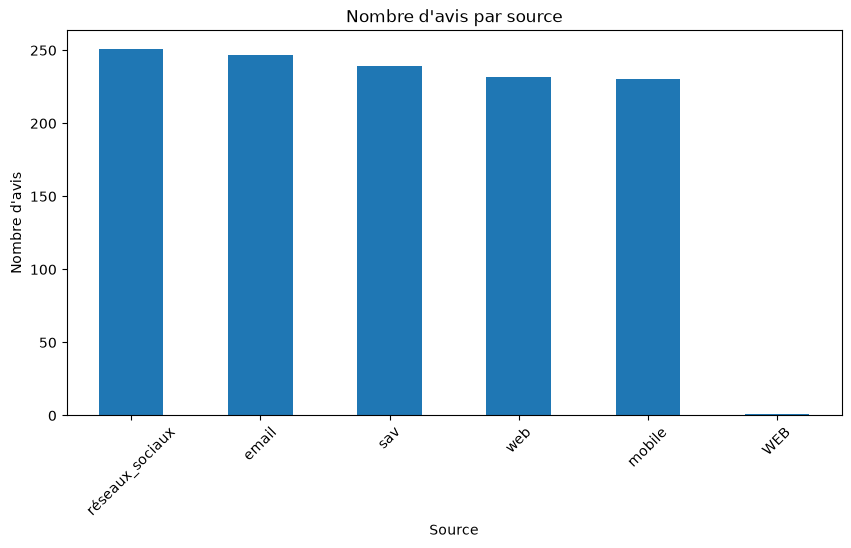

In [24]:
plt.figure(figsize=(10, 5))

avis_par_source.plot(kind="bar")

plt.title("Nombre d'avis par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)

plt.show()

#### Lecture 
La source la plus représentée est celle qui possède le plus grand nombre d'avis. La comparaison des effectifs permet également d'identifier les éventuels écarts de représentation entre les différentes sources.

### 1.16. Répartition des avis par produit

La répartition des avis par produit permet de vérifier si les produits sont représentés de manière homogène dans le corpus.

In [25]:
avis_par_produit = df["produit"].value_counts()

avis_par_produit

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64

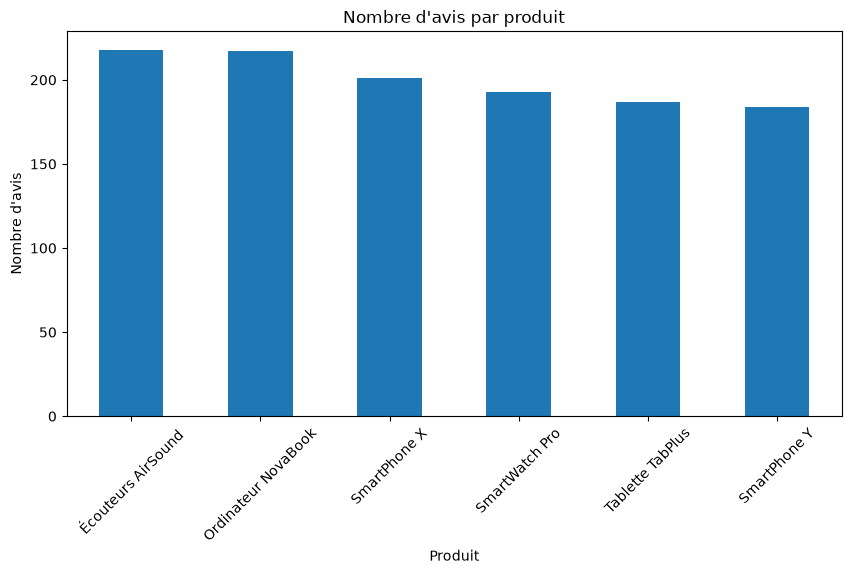

In [26]:
plt.figure(figsize=(10, 5))

avis_par_produit.plot(kind="bar")

plt.title("Nombre d'avis par produit")
plt.xlabel("Produit")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)

plt.show()

#### Lecture

La distribution obtenue permet de comparer la représentation des différents produits dans le corpus et d'identifier les éventuels écarts d'effectifs.

### 2.1. Suppression des valeurs manquantes de texte

Les lignes dont la colonne `texte` contient une valeur manquante sont supprimées.

Cette étape permet de travailler uniquement sur des observations disposant d'un texte exploitable.

In [27]:
df_clean = df.dropna(subset=["texte"]).copy()

print(f"Nombre de lignes avant suppression : {len(df)}")
print(f"Nombre de lignes après suppression : {len(df_clean)}")
print(f"Nombre de lignes supprimées : {len(df) - len(df_clean)}")

Nombre de lignes avant suppression : 1200
Nombre de lignes après suppression : 1195
Nombre de lignes supprimées : 5


### 2.2. Suppression des doublons

Les doublons sont supprimés sur la colonne `texte`.

Un même avis textuel ne doit pas être comptabilisé plusieurs fois dans le corpus utilisé pour la suite du traitement.

In [29]:
avant = len(df_clean)

df_clean = df_clean.drop_duplicates(
    subset=["texte"],
    keep="first"
).copy()

print(f"Nombre de doublons supprimés : {avant - len(df_clean)}")
print(f"Nombre de lignes restantes : {len(df_clean)}")

Nombre de doublons supprimés : 0
Nombre de lignes restantes : 318


### 2.3. Suppression des URLs

Les URLs sont supprimées car elles apportent généralement peu d'information sémantique directement exploitable pour une classification de sentiment.

Le contenu textuel de l'avis est conservé.

In [30]:
import re

In [31]:
df_clean["texte"] = df_clean["texte"].str.replace(
    r"https?://\S+|www\.\S+",
    "",
    regex=True
)

### 2.4. Traitement des mentions et hashtags

Les mentions et hashtags sont conservés sous leur forme textuelle, mais les caractères `@` et `#` sont supprimés.

Cette stratégie permet de conserver les mots potentiellement utiles à la classification du sentiment tout en supprimant les marqueurs propres aux réseaux sociaux.

In [32]:
df_clean["texte"] = df_clean["texte"].str.replace(
    r"[@#](\w+)",
    r"\1",
    regex=True
)

### 2.5. Nettoyage des espaces

Les espaces multiples sont remplacés par un seul espace et les espaces présents au début ou à la fin du texte sont supprimés.

In [33]:
df_clean["texte"] = (
    df_clean["texte"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

### 2.6. Traitement de la ponctuation

La ponctuation est supprimée afin de réduire les variations superficielles entre les textes.

Les caractères alphabétiques, les chiffres et les espaces sont conservés.

In [34]:
df_clean["texte"] = df_clean["texte"].str.replace(
    r"[^\w\s]",
    " ",
    regex=True
)

df_clean["texte"] = (
    df_clean["texte"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

### 2.7. Fonction de nettoyage

Les différentes opérations précédentes sont regroupées dans une fonction afin de rendre le nettoyage reproductible, lisible et facilement maintenable.

In [35]:
def nettoyer_texte(texte):
    texte = str(texte)

    # supprimer les URLs
    texte = re.sub(r"https?://\S+|www\.\S+", " ", texte)

    # conserver les mots des mentions et hashtags
    texte = re.sub(r"[@#](\w+)", r"\1", texte)

    # supprimer la ponctuation
    texte = re.sub(r"[^\w\s]", " ", texte)

    # nettoyer les espaces
    texte = re.sub(r"\s+", " ", texte).strip()

    return texte

In [36]:
# verifier la fonction sur quelques textes

df_clean["texte"].head(5).apply(nettoyer_texte)

0             Très bonne expérience simple et efficace
1                     Très satisfait de mon achat avis
2                      Produit parfait rien à signaler
3             Produit excellent je suis très satisfait
4    LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...
Name: texte, dtype: str

### 2.8. Création de la colonne texte_clean

La colonne `texte_clean` contient le résultat du nettoyage appliqué au texte original.

La colonne `texte` reste ainsi disponible comme référence du contenu avant nettoyage.

In [38]:
df_clean["texte_clean"] = (
    df.loc[df_clean.index, "texte"]
    .apply(nettoyer_texte)
)

### 2.9. Vérification du nettoyage

Les dix premières observations sont comparées afin de vérifier concrètement les transformations appliquées entre le texte original et le texte nettoyé.

In [39]:
df_clean[["texte", "texte_clean"]].head(10)

,texte,texte_clean
0,Très bonne expérience simple et efficace,Très bonne expérience simple et efficace
1,Très satisfait de mon achat avis,Très satisfait de mon achat avis
2,Produit parfait rien à signaler,Produit parfait rien à signaler
3,Produit excellent je suis très satisfait,Produit excellent je suis très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...
5,Très satisfait de mon achat,Très satisfait de mon achat
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7,Très satisfait de mon achat,Très satisfait de mon achat
8,Le produit correspond globalement à la descrip...,Le produit correspond globalement à la descrip...
9,client Livraison rapide et produit conforme à ...,client Livraison rapide et produit conforme à ...


### 3.1. Limites de split()

La méthode `split()` sépare principalement le texte selon les espaces.

Elle ne constitue pas une véritable tokenisation NLP car elle ne prend pas correctement en compte les différents éléments linguistiques comme la ponctuation, les contractions ou certaines structures propres au langage naturel.

Une bibliothèque spécialisée comme NLTK permet d'utiliser des règles de tokenisation adaptées au traitement automatique du langage.

### 3.2. Tokenisation avec NLTK

La bibliothèque NLTK est utilisée pour effectuer la tokenisation des textes nettoyés et mesurer le nombre de tokens de chaque avis.

In [ ]:
%pip install nltk

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 7.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   ---------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [43]:
import nltk
from nltk.tokenize import word_tokenize

In [44]:
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Invite\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Invite\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [45]:
df_clean["tokens"] = df_clean["texte_clean"].apply(word_tokenize)
df_clean["nombre_tokens"] = df_clean["tokens"].str.len()

#### a. Nombre de tokens par texte

Le nombre de tokens est enregistré dans la colonne `nombre_tokens`.

In [46]:
df_clean[["texte_clean", "nombre_tokens"]].head(10)

,texte_clean,nombre_tokens
0,Très bonne expérience simple et efficace,6
1,Très satisfait de mon achat avis,6
2,Produit parfait rien à signaler,5
3,Produit excellent je suis très satisfait,6
4,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...,10
5,Très satisfait de mon achat,5
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,7
7,Très satisfait de mon achat,5
8,Le produit correspond globalement à la descrip...,7
9,client Livraison rapide et produit conforme à ...,9


#### b. Nombre moyen de tokens

La moyenne du nombre de tokens permet d'estimer la longueur moyenne des avis après nettoyage.

In [47]:
nombre_moyen_tokens = df_clean["nombre_tokens"].mean()

print(f"Nombre moyen de tokens : {nombre_moyen_tokens:.2f}")

Nombre moyen de tokens : 7.05


#### c. Texte avec le plus grand nombre de tokens

L'avis contenant le plus grand nombre de tokens est identifié afin d'observer le texte le plus long du corpus après nettoyage.

In [48]:
indice_max = df_clean["nombre_tokens"].idxmax()

print(f"Nombre de tokens : {df_clean.loc[indice_max, 'nombre_tokens']}")
print(f"Texte : {df_clean.loc[indice_max, 'texte_clean']}")

Nombre de tokens : 120
Texte : Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue


#### d. Texte avec le plus petit nombre de tokens

L'avis contenant le plus petit nombre de tokens est identifié afin d'observer les textes les plus courts après nettoyage.

In [49]:
indice_min = df_clean["nombre_tokens"].idxmin()

print(f"Nombre de tokens : {df_clean.loc[indice_min, 'nombre_tokens']}")
print(f"Texte : {df_clean.loc[indice_min, 'texte_clean']}")

Nombre de tokens : 0
Texte : 


### 4.1. Uniformisation de la casse

Les textes sont convertis en minuscules afin de considérer comme identiques les mots qui diffèrent uniquement par leur casse.

Par exemple, `Excellent`, `EXCELLENT` et `excellent` doivent être traités comme le même terme lors de la représentation du corpus.

In [50]:
df_clean["texte_final"] = df_clean["texte_clean"].str.lower()

### 4.2. Traitement des accents

Les accents ne sont pas systématiquement supprimés dans un corpus français.

Ils font partie de l'orthographe et peuvent contribuer à distinguer correctement les mots. Dans notre corpus français, ils sont donc conservés.

### 4.3. Stop words à supprimer

Les stop words très fréquents et peu discriminants pour la classification peuvent être supprimés afin de réduire le bruit et la taille de la représentation textuelle.

Cependant, dans une classification de sentiment, cette suppression doit être réalisée avec prudence car certains mots grammaticaux peuvent participer au sens du sentiment exprimé.

### 4.4. Stop words à conserver

Les mots pouvant modifier ou inverser le sentiment doivent être conservés.

En particulier, les termes de négation comme `ne`, `pas`, `jamais` ou `plus` peuvent être importants pour distinguer un sentiment positif d'un sentiment négatif.

### 4.5. Choix entre stemming et lemmatisation

La lemmatisation est retenue car elle permet de ramener les mots à leur forme canonique tout en tenant compte davantage de leur contexte linguistique.

Pour un corpus français destiné à une classification de sentiment, cette approche conserve une représentation plus interprétable que le stemming, qui peut produire des formes tronquées.

In [57]:
%pip install spacy

Note: you may need to restart the kernel to use updated packages.


In [58]:
import spacy

In [60]:
nlp = spacy.load("fr_core_news_sm")

In [61]:
def lemmatiser_texte(texte):
    doc = nlp(texte)
    
    return " ".join(
        token.lemma_
        for token in doc
        if not token.is_space
    )

### 4.6. Création de la colonne texte_final

La colonne `texte_final` contient la représentation normalisée des avis après nettoyage, passage en minuscules et lemmatisation.

In [62]:
df_clean["texte_final"] = (
    df_clean["texte_clean"]
    .str.lower()
    .apply(lemmatiser_texte)
)

### 4.7. Vérification des trois versions du texte

Les colonnes `texte`, `texte_clean` et `texte_final` sont affichées côte à côte sur les dix premières observations afin de vérifier l'évolution du texte au cours du pipeline.

In [63]:
df_clean[
    ["texte", "texte_clean", "texte_final"]
].head(10)

,texte,texte_clean,texte_final
0,Très bonne expérience simple et efficace,Très bonne expérience simple et efficace,très bon expérience simple et efficace
1,Très satisfait de mon achat avis,Très satisfait de mon achat avis,très satisfait de mon achat avis
2,Produit parfait rien à signaler,Produit parfait rien à signaler,produit parfaire rien à signaler
3,Produit excellent je suis très satisfait,Produit excellent je suis très satisfait,produit excellent je être très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...,le batterie tenir vraiment bien et l écran êtr...
5,Très satisfait de mon achat,Très satisfait de mon achat,très satisfait de mon achat
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,service client réactif et commande recevoir ra...
7,Très satisfait de mon achat,Très satisfait de mon achat,très satisfait de mon achat
8,Le produit correspond globalement à la descrip...,Le produit correspond globalement à la descrip...,le produit correspondre globalement à le descr...
9,client Livraison rapide et produit conforme à ...,client Livraison rapide et produit conforme à ...,client livraison rapide et produire conforme à...


### 4.8. Sauvegarde du dataset nettoyé

Le dataset obtenu après nettoyage et normalisation est sauvegardé dans `data/smart_reviews_cleaned.csv`.

Les colonnes intermédiaires de tokenisation ne sont pas nécessaires dans le fichier final.

In [64]:
colonnes_finales = [
    "id_avis",
    "date",
    "source",
    "produit",
    "texte",
    "texte_clean",
    "texte_final",
    "sentiment",
    "note",
    "langue"
]

df_clean[colonnes_finales].to_csv(
    "../data/smart_reviews_cleaned.csv",
    index=False
)

In [ ]:
# verif

df_verification = pd.read_csv(
    "../data/smart_reviews_cleaned.csv"
)

df_verification.head()

,id_avis,date,source,produit,texte,texte_clean,texte_final,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,Très bonne expérience simple et efficace,Très bonne expérience simple et efficace,très bon expérience simple et efficace,positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat avis,Très satisfait de mon achat avis,très satisfait de mon achat avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,Produit parfait rien à signaler,Produit parfait rien à signaler,produit parfaire rien à signaler,positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,Produit excellent je suis très satisfait,Produit excellent je suis très satisfait,produit excellent je être très satisfait,positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...,le batterie tenir vraiment bien et l écran êtr...,positif,5,fr


### 5.1. Découpage du dataset

Le dataset est séparé en deux ensembles :

* `train` pour l'entraînement ;
* `test` pour l'évaluation.

Le jeu de test représente 20 % des données. Le paramètre `random_state` garantit la reproductibilité du découpage et `stratify` conserve les proportions des classes de sentiment dans les deux ensembles.

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
X = df_clean["texte_final"]
y = df_clean["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [68]:

# verif
print(f"Nombre d'observations d'entraînement : {len(X_train)}")
print(f"Nombre d'observations de test : {len(X_test)}")

Nombre d'observations d'entraînement : 254
Nombre d'observations de test : 64


In [69]:
print(f"Proportion train : {len(X_train) / len(df_clean):.2%}")
print(f"Proportion test : {len(X_test) / len(df_clean):.2%}")

Proportion train : 79.87%
Proportion test : 20.13%


### 5.2. Vérification de la stratification

La répartition des classes `sentiment` est comparée entre le dataset complet, le jeu d'entraînement et le jeu de test.

L'objectif est de vérifier que les proportions des différentes classes restent proches après le découpage.

In [70]:
repartition_complete = y.value_counts(normalize=True).sort_index()
repartition_train = y_train.value_counts(normalize=True).sort_index()
repartition_test = y_test.value_counts(normalize=True).sort_index()

comparaison_classes = pd.DataFrame({
    "dataset": repartition_complete,
    "train": repartition_train,
    "test": repartition_test
}) * 100

comparaison_classes.round(2)

,dataset,train,test
sentiment,,,
negatif,24.84,24.80,25.0
neutre,24.84,24.80,25.0
positif,50.31,50.39,50.0


### 6.1. Vectorisation Bag of Words

La méthode Bag of Words représente chaque texte par les mots présents dans le vocabulaire.

Chaque colonne de la matrice correspond à un terme du vocabulaire et chaque ligne correspond à un texte.

In [71]:
from sklearn.feature_extraction.text import CountVectorizer

In [72]:
vectorizer_bow = CountVectorizer()

X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)

In [ ]:
# verif

print(f"Taille de la matrice train : {X_train_bow.shape}")
print(f"Taille de la matrice test : {X_test_bow.shape}")

Taille de la matrice train : (254, 92)
Taille de la matrice test : (64, 92)


In [74]:
vocabulaire_bow = vectorizer_bow.get_feature_names_out()

print(f"Taille du vocabulaire : {len(vocabulaire_bow)}")
print("Extrait du vocabulaire :")
print(vocabulaire_bow[:20])

Taille du vocabulaire : 92
Extrait du vocabulaire :
['achat' 'assez' 'attente' 'au' 'avi' 'avir' 'avis' 'avoir' 'batterie'
 'beaucoup' 'bien' 'bon' 'ce' 'client' 'commande' 'conforme' 'correct'
 'correspondre' 'dans' 'de']


In [ ]:
# extrait de la matrice

X_train_bow[:5, :10].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]])

### 6.2. Vectorisation TF-IDF

La méthode TF-IDF pondère les termes en fonction de leur fréquence dans les documents et de leur fréquence dans l'ensemble du corpus.

Les termes très fréquents dans les documents sont ainsi moins discriminants que les termes caractéristiques de certains documents.

In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [77]:
vectorizer_tfidf = TfidfVectorizer()

X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

In [78]:
# taille

print(f"Taille de la matrice train : {X_train_tfidf.shape}")
print(f"Taille de la matrice test : {X_test_tfidf.shape}")

Taille de la matrice train : (254, 92)
Taille de la matrice test : (64, 92)


In [79]:
# vocabulaire

vocabulaire_tfidf = vectorizer_tfidf.get_feature_names_out()

print(f"Taille du vocabulaire : {len(vocabulaire_tfidf)}")
print("Extrait du vocabulaire :")
print(vocabulaire_tfidf[:20])

Taille du vocabulaire : 92
Extrait du vocabulaire :
['achat' 'assez' 'attente' 'au' 'avi' 'avir' 'avis' 'avoir' 'batterie'
 'beaucoup' 'bien' 'bon' 'ce' 'client' 'commande' 'conforme' 'correct'
 'correspondre' 'dans' 'de']


In [80]:
# matrice

X_train_tfidf[:5, :10].toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.43450631, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]])

### 6.3. Vectorisation TF-IDF avec unigrams et bigrams

Une seconde représentation TF-IDF est construite en utilisant des unigrammes et des bigrammes.

Les unigrammes correspondent aux mots seuls tandis que les bigrammes correspondent aux groupes de deux mots consécutifs.

Cette représentation permet notamment de conserver certaines associations de mots utiles pour l'analyse du sentiment.

In [81]:
vectorizer_tfidf_ngram = TfidfVectorizer(
    ngram_range=(1, 2)
)

X_train_tfidf_ngram = vectorizer_tfidf_ngram.fit_transform(X_train)
X_test_tfidf_ngram = vectorizer_tfidf_ngram.transform(X_test)

In [82]:
# taille

print(f"Taille de la matrice train : {X_train_tfidf_ngram.shape}")
print(f"Taille de la matrice test : {X_test_tfidf_ngram.shape}")

Taille de la matrice train : (254, 255)
Taille de la matrice test : (64, 255)


In [83]:
# vocabulaire

vocabulaire_tfidf_ngram = (
    vectorizer_tfidf_ngram
    .get_feature_names_out()
)

print(f"Taille du vocabulaire : {len(vocabulaire_tfidf_ngram)}")
print("Extrait du vocabulaire :")
print(vocabulaire_tfidf_ngram[:30])

Taille du vocabulaire : 255
Extrait du vocabulaire :
['achat' 'achat avis' 'assez' 'assez simple' 'attente' 'attente avis' 'au'
 'au rendez' 'avi' 'avir' 'avis' 'avoir' 'avoir pas' 'avoir être'
 'batterie' 'batterie se' 'batterie tenir' 'beaucoup' 'beaucoup trop'
 'bien' 'bien et' 'bien mais' 'bon' 'bon expérience' 'bon produit' 'ce'
 'ce prix' 'ce produit' 'client' 'client avoir']


In [84]:
# matrice 

X_train_tfidf_ngram[:5, :10].toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.29752511,
        0.        , 0.        , 0.        , 0.        , 0.        ]])